#### **Load The Dependancies**

In [325]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import joblib
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

#### **Load the Description Dataset**

In [326]:
df = pd.read_excel("segmentation_model_data_description.xlsx")

In [327]:
print(df.head().to_string())

                Variable                                                             Description
0        customer_number                                                  unique customer number
1            age_in_loop                                    period customer has been on LOOP app
2                usr_age                                                     age of the customer
3  customer_credit_limit                                            credit limit of the customer
4          inflow_amt_3m  inflow amount received by customer between 1st April to 30th June 2025


In [328]:
df.shape

(44, 2)

#### **Load the Actual Segmentation Dataset**

In [329]:
df1 = pd.read_excel("segmentation_model_data.xlsx")

#### **Data Eyeballing**

In [330]:
print(df1.head().to_string())

  customer_number  age_in_loop  usr_age  customer_credit_limit  inflow_amt_3m  inflow_cnt_3m  outflow_amt_3m  outflow_cnt_3m  inflow_amt_6m  inflow_cnt_6m  outflow_amt_6m  outflow_cnt_6m  invest_txn_cnt_3m  invest_txn_amt_3m  invest_txn_cnt_6m  invest_txn_amt_6m  goals_txn_cnt_3m  goals_txn_amt_3m  goals_txn_cnt_6m  goals_txn_amt_6m  bill_txn_cnt_3m  bill_txn_amt_3m  bill_txn_cnt_6m  bill_txn_amt_6m  lipa_na_mpesa_txn_cnt_3m  lipa_na_mpesa_txn_amt_3m  lipa_na_mpesa_txn_cnt_6m  lipa_na_mpesa_txn_amt_6m  loop_biz_amt_3m  loop_biz_cnt_3m  loop_biz_amt_6m  loop_biz_cnt_6m  bill_count  sto_count has_virtual_card  linked_cards_cnt  discover_deals_txn_cnt_3m  discover_deals_txn_amt_3m  discover_deals_txn_cnt_6m  discover_deas_txn_amt_6m  card_txn_cnt_3m  card_txn_amt_3m  card_txn_cnt_6m  card_txn_amt_6m
0              C1         1512     29.0                    0.0        10250.0             17        10723.76              27       42070.88             47        54924.02              93      

In [331]:
df1.shape

(10000, 44)

In [332]:
df1.columns

Index(['customer_number', 'age_in_loop', 'usr_age', 'customer_credit_limit',
       'inflow_amt_3m', 'inflow_cnt_3m', 'outflow_amt_3m', 'outflow_cnt_3m',
       'inflow_amt_6m', 'inflow_cnt_6m', 'outflow_amt_6m', 'outflow_cnt_6m',
       'invest_txn_cnt_3m', 'invest_txn_amt_3m', 'invest_txn_cnt_6m',
       'invest_txn_amt_6m', 'goals_txn_cnt_3m', 'goals_txn_amt_3m',
       'goals_txn_cnt_6m', 'goals_txn_amt_6m', 'bill_txn_cnt_3m',
       'bill_txn_amt_3m', 'bill_txn_cnt_6m', 'bill_txn_amt_6m',
       'lipa_na_mpesa_txn_cnt_3m', 'lipa_na_mpesa_txn_amt_3m',
       'lipa_na_mpesa_txn_cnt_6m', 'lipa_na_mpesa_txn_amt_6m',
       'loop_biz_amt_3m', 'loop_biz_cnt_3m', 'loop_biz_amt_6m',
       'loop_biz_cnt_6m', 'bill_count', 'sto_count', 'has_virtual_card',
       'linked_cards_cnt', 'discover_deals_txn_cnt_3m',
       'discover_deals_txn_amt_3m', 'discover_deals_txn_cnt_6m',
       'discover_deas_txn_amt_6m', 'card_txn_cnt_3m', 'card_txn_amt_3m',
       'card_txn_cnt_6m', 'card_txn_amt_6m']

##### **Check for float Features**

In [333]:
float_cols = df1.select_dtypes(include=['float']).columns.tolist()

print(float_cols)

['usr_age', 'customer_credit_limit', 'inflow_amt_3m', 'outflow_amt_3m', 'inflow_amt_6m', 'outflow_amt_6m', 'invest_txn_amt_3m', 'invest_txn_amt_6m', 'bill_txn_amt_3m', 'bill_txn_amt_6m', 'lipa_na_mpesa_txn_amt_3m', 'lipa_na_mpesa_txn_amt_6m', 'bill_count', 'sto_count', 'linked_cards_cnt', 'discover_deals_txn_cnt_3m', 'discover_deals_txn_amt_3m', 'discover_deals_txn_cnt_6m', 'discover_deas_txn_amt_6m', 'card_txn_cnt_3m', 'card_txn_amt_3m', 'card_txn_cnt_6m', 'card_txn_amt_6m']


##### **Check for Count(Integer) Features**

In [334]:
int_cols = df1.select_dtypes(include=['int']).columns.tolist()

print(int_cols)

['age_in_loop', 'inflow_cnt_3m', 'outflow_cnt_3m', 'inflow_cnt_6m', 'outflow_cnt_6m', 'invest_txn_cnt_3m', 'invest_txn_cnt_6m', 'goals_txn_cnt_3m', 'goals_txn_amt_3m', 'goals_txn_cnt_6m', 'goals_txn_amt_6m', 'bill_txn_cnt_3m', 'bill_txn_cnt_6m', 'lipa_na_mpesa_txn_cnt_3m', 'lipa_na_mpesa_txn_cnt_6m', 'loop_biz_amt_3m', 'loop_biz_cnt_3m', 'loop_biz_amt_6m', 'loop_biz_cnt_6m']


##### **Check for Date Features if any**

In [335]:
datetime_cols = df1.select_dtypes(include=['datetime']).columns.tolist()

print(datetime_cols)

[]


##### **Check for Categorical Features**

In [336]:
cat_cols = df1.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(cat_cols)

['customer_number', 'has_virtual_card']


#### **Check for the composition of missing values**

In [337]:
num_cols = df1.select_dtypes(include=['number'])
cat_cols = df1.select_dtypes(exclude=['number'])

num_missing = num_cols.isnull().sum().sum()
num_total = num_cols.shape[0] * num_cols.shape[1]
num_missing_percent = (num_missing / num_total) * 100

cat_missing = cat_cols.isnull().sum().sum()
cat_total = cat_cols.shape[0] * cat_cols.shape[1]
cat_missing_percent = (cat_missing / cat_total) * 100

print(f"Numerical Missing Percentage: {num_missing_percent:.2f}%")
print(f"Categorical Missing Percentage: {cat_missing_percent:.2f}%")

Numerical Missing Percentage: 22.02%
Categorical Missing Percentage: 0.00%


#### **Check for Missing value percentage per feature**

In [338]:
num_cols = df1.select_dtypes(include=['number'])

num_missing_summary = pd.DataFrame({
    'Missing_Count': num_cols.isnull().sum(),
    'Missing_Percent': num_cols.isnull().mean() * 100
})
num_missing_summary = num_missing_summary[num_missing_summary['Missing_Count'] > 0]

print("\nNumerical Features Missing Summary:")
print(num_missing_summary)


Numerical Features Missing Summary:
                           Missing_Count  Missing_Percent
usr_age                                9             0.09
customer_credit_limit                 37             0.37
bill_count                          8064            80.64
sto_count                           9672            96.72
linked_cards_cnt                    9567            95.67
discover_deals_txn_cnt_3m           9986            99.86
discover_deals_txn_amt_3m           9986            99.86
discover_deals_txn_cnt_6m           9986            99.86
discover_deas_txn_amt_6m            9986            99.86
card_txn_cnt_3m                     6303            63.03
card_txn_amt_3m                     6303            63.03
card_txn_cnt_6m                     6303            63.03
card_txn_amt_6m                     6303            63.03


#### **Features Comprising of Negative values**

In [339]:
numeric_cols = df1.select_dtypes(include=['number']).columns
negatives = pd.DataFrame({
    'Negative_Count': [(df1[col] < 0).sum() for col in numeric_cols],
    'Negative_Percent': [(df1[col] < 0).mean() * 100 for col in numeric_cols]
}, index=numeric_cols)

print(negatives)

                           Negative_Count  Negative_Percent
age_in_loop                             0               0.0
usr_age                                 0               0.0
customer_credit_limit                   0               0.0
inflow_amt_3m                           0               0.0
inflow_cnt_3m                           0               0.0
outflow_amt_3m                          0               0.0
outflow_cnt_3m                          0               0.0
inflow_amt_6m                           0               0.0
inflow_cnt_6m                           0               0.0
outflow_amt_6m                          0               0.0
outflow_cnt_6m                          0               0.0
invest_txn_cnt_3m                       0               0.0
invest_txn_amt_3m                       0               0.0
invest_txn_cnt_6m                       0               0.0
invest_txn_amt_6m                       0               0.0
goals_txn_cnt_3m                        

#### **Dealing with Missing Values**

In [340]:
df1['usr_age'].fillna(df1['usr_age'].median(), inplace=True)
df1['customer_credit_limit'].fillna(df1['customer_credit_limit'].median(), inplace=True)

#### **Explanation**
* I handled low-missing features like `usr_age` and `customer_credit_limit` using median imputation because the proportion of missing values was negligible and unlikely to distort the overall distribution. The median is preferred over the mean since it is more robust to outliers, especially in financial data where extreme values are common. This ensures we retain almost all observations while preserving the natural structure of the data, which is important for stable clustering.

In [341]:
df1['has_card_txn'] = df1['card_txn_cnt_3m'].notnull().astype(int)
df1['has_bill'] = df1['bill_count'].notnull().astype(int)

In [342]:
card_cols = [col for col in df1.columns if 'card_txn' in col]
df1[card_cols] = df1[card_cols].fillna(0)

df1['bill_count'] = df1['bill_count'].fillna(0)

#### **Explanation**
* For moderately missing behavioral features such as card transactions and billing activity, we treated missingness as a meaningful signal rather than just a data quality issue. By creating indicator variables (`has_card_txn`, `has_bill`), we explicitly capture whether a customer engages with these services, while filling missing values with zero reflects “no activity” in a logical and interpretable way. This dual approach prevents loss of information and allows the model to distinguish between inactive users and active ones, improving segmentation quality.

In [343]:
drop_cols = [
    'sto_count', 'linked_cards_cnt',
    'discover_deals_txn_cnt_3m', 'discover_deals_txn_amt_3m',
    'discover_deals_txn_cnt_6m', 'discover_deas_txn_amt_6m'
]

df1.drop(columns=drop_cols, inplace=True)


#### **Explanation**
* For features with extremely high missingness (above 90%), such as `discover_deals_*`, `sto_count`, and `linked_cards_cnt`, we chose to drop them because they provide little reliable information and can introduce noise into clustering. Keeping such sparse features—even if filled with zeros—would skew distance calculations and lead to misleading groupings driven by data sparsity rather than actual customer behavior. Removing them ensures that the model focuses only on informative, consistent features that contribute meaningfully to identifying distinct customer segments.


#### **Check again for Missing values**

In [344]:
num_cols = df1.select_dtypes(include=['number'])

num_missing_summary = pd.DataFrame({
    'Missing_Count': num_cols.isnull().sum(),
    'Missing_Percent': num_cols.isnull().mean() * 100
})
num_missing_summary = num_missing_summary[num_missing_summary['Missing_Count'] > 0]

print("\nNumerical Features Missing Summary:")
print(num_missing_summary)


Numerical Features Missing Summary:
Empty DataFrame
Columns: [Missing_Count, Missing_Percent]
Index: []


#### **Observation** 
* No missing values now 

### **Exploratory Data Analysis**

In [345]:
df2= df1.copy()

In [346]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_number           10000 non-null  object 
 1   age_in_loop               10000 non-null  int64  
 2   usr_age                   10000 non-null  float64
 3   customer_credit_limit     10000 non-null  float64
 4   inflow_amt_3m             10000 non-null  float64
 5   inflow_cnt_3m             10000 non-null  int64  
 6   outflow_amt_3m            10000 non-null  float64
 7   outflow_cnt_3m            10000 non-null  int64  
 8   inflow_amt_6m             10000 non-null  float64
 9   inflow_cnt_6m             10000 non-null  int64  
 10  outflow_amt_6m            10000 non-null  float64
 11  outflow_cnt_6m            10000 non-null  int64  
 12  invest_txn_cnt_3m         10000 non-null  int64  
 13  invest_txn_amt_3m         10000 non-null  float64
 14  invest_

In [347]:
df2.describe(include='object').T

,count,unique,top,freq
customer_number,10000,10000,C1,1
has_virtual_card,10000,2,No,9461


In [348]:
df2.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
age_in_loop,10000.0,1154.737800,9.654263e+02,196.0,343.0,639.0,2085.0000,3308.00
usr_age,10000.0,33.327100,8.819755e+00,19.0,27.0,31.0,38.0000,99.00
customer_credit_limit,10000.0,1184.650000,4.206774e+03,0.0,0.0,0.0,0.0000,30000.00
inflow_amt_3m,10000.0,103707.174228,5.850434e+05,0.0,0.0,1200.0,26932.5000,22279481.76
inflow_cnt_3m,10000.0,9.927300,9.718250e+01,0.0,0.0,2.0,7.0000,9224.00
outflow_amt_3m,10000.0,110297.933968,6.088345e+05,0.0,0.0,1201.5,28985.7275,22870447.04
outflow_cnt_3m,10000.0,24.163400,6.785168e+01,0.0,0.0,3.0,20.0000,2236.00
inflow_amt_6m,10000.0,204423.175163,1.099888e+06,0.0,500.0,6359.5,62217.0000,47804619.14
inflow_cnt_6m,10000.0,18.931800,1.517430e+02,0.0,1.0,4.0,14.0000,14129.00
outflow_amt_6m,10000.0,221569.439526,1.170108e+06,0.0,190.0,5591.0,66807.4100,52269172.64


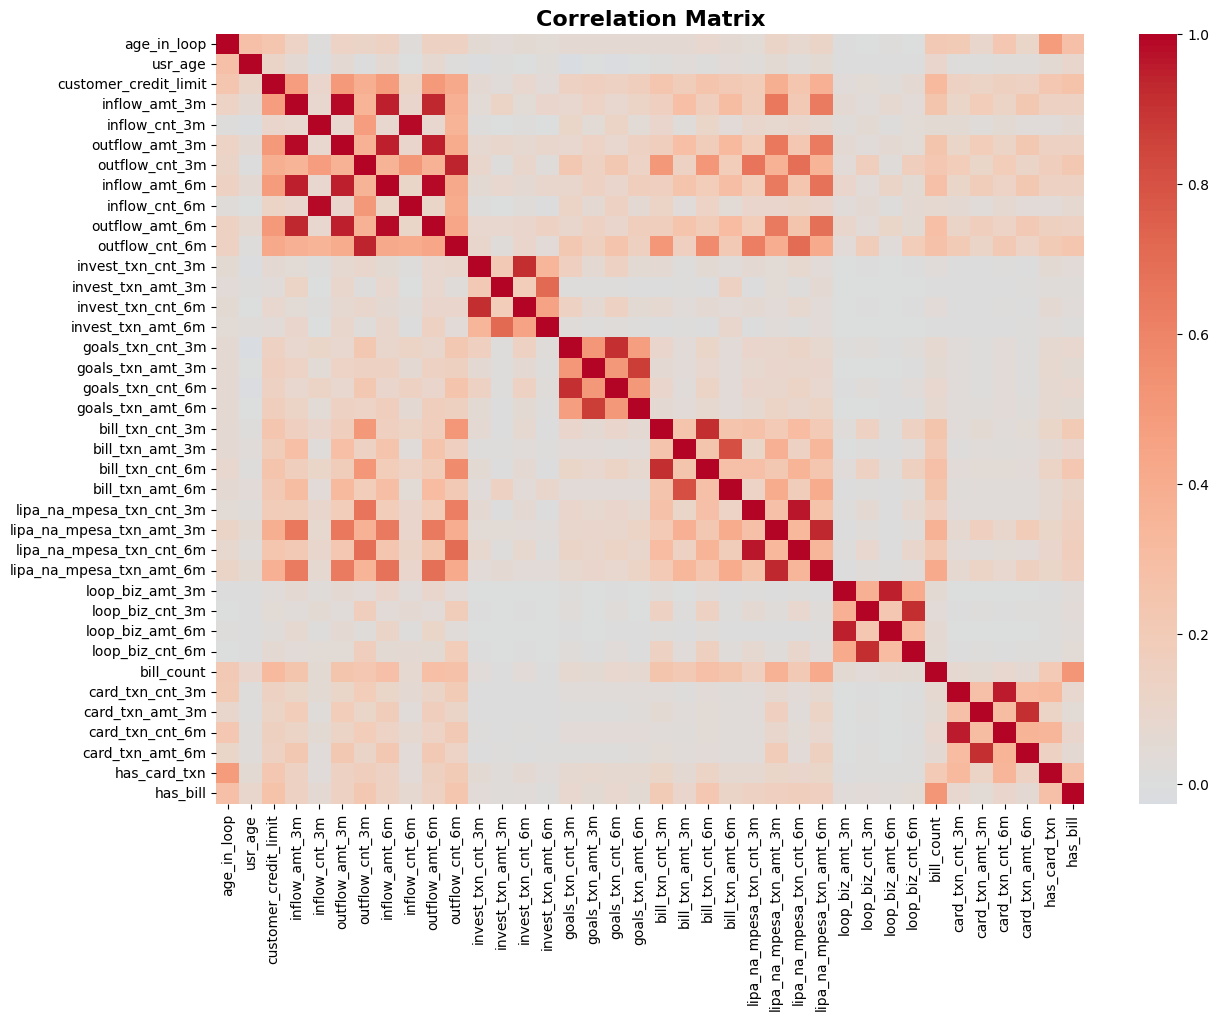

In [349]:
num_df = df2.select_dtypes(include=[np.number])
num_df = num_df.drop(columns=['customer_number'], errors='ignore')
corr = num_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix', fontweight='bold', fontsize=16)
plt.show()

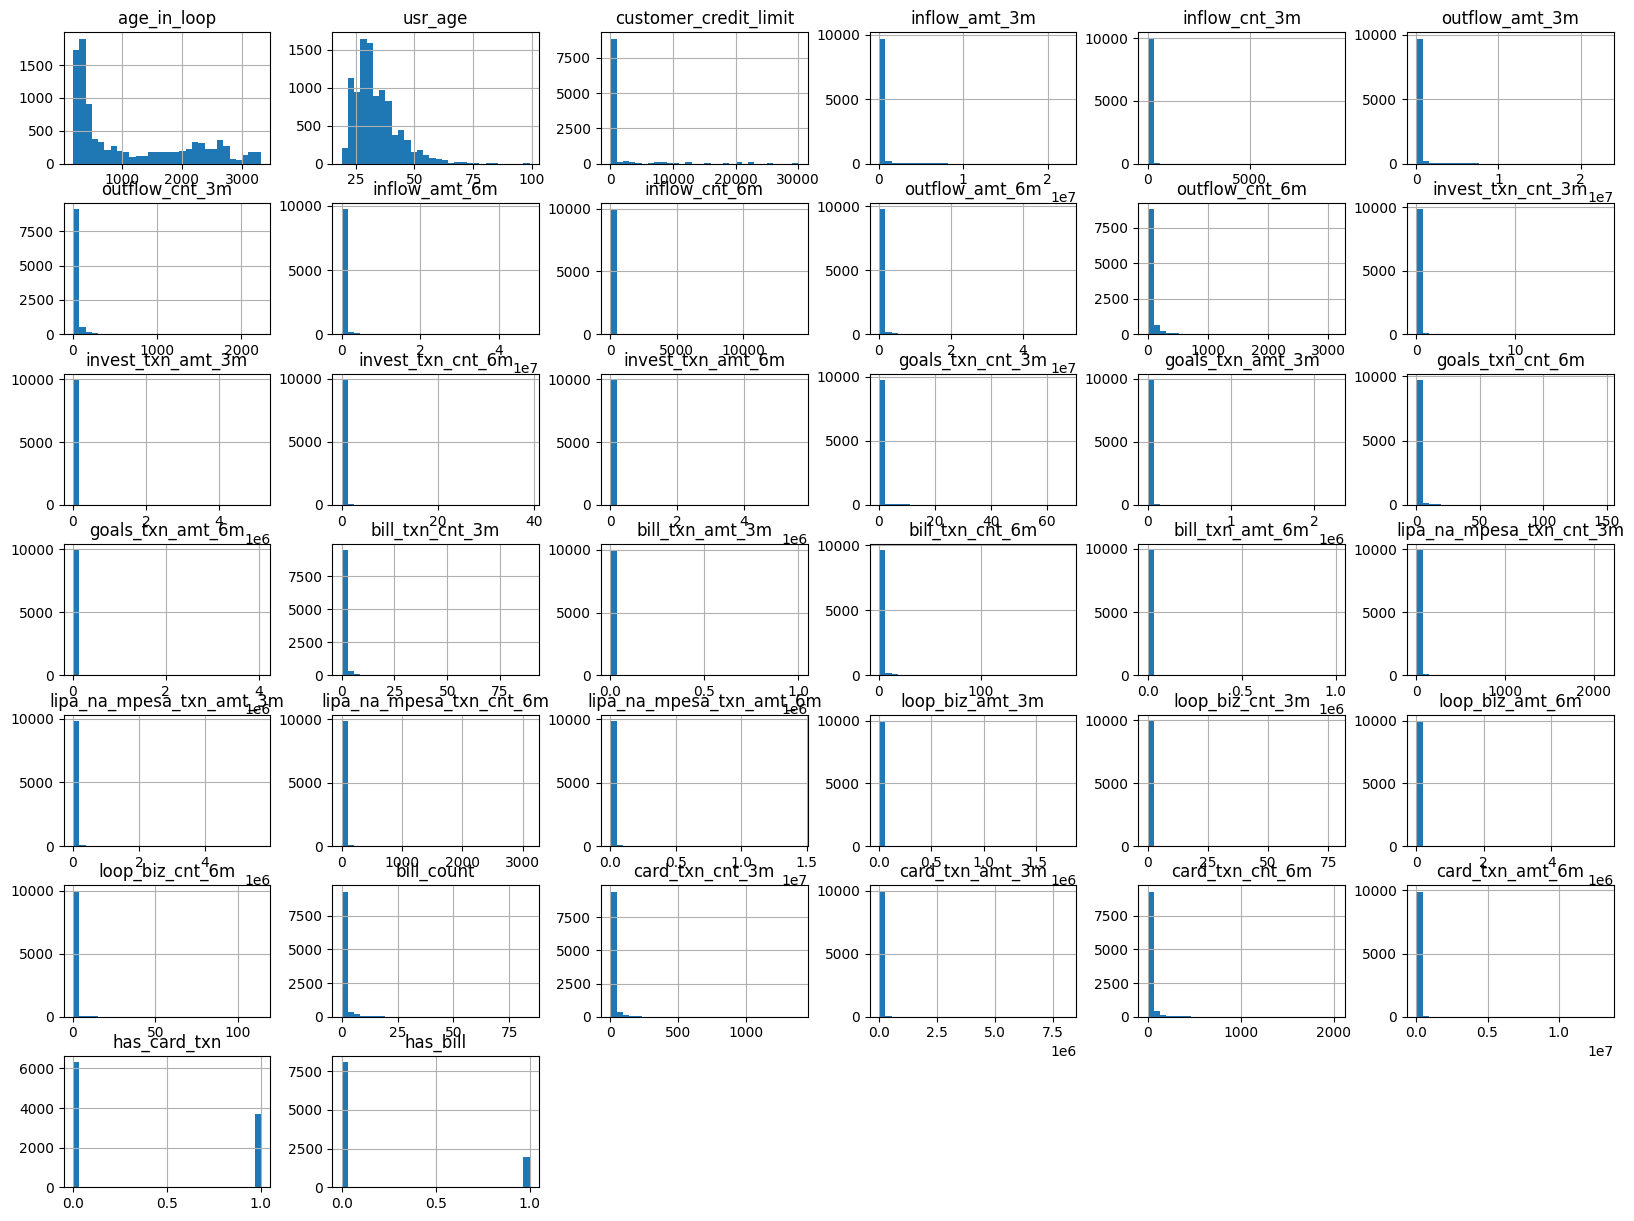

In [350]:
num_cols = df2.select_dtypes(include=['int64','float64']).columns

df2[num_cols].hist(figsize=(20,15), bins=30)
plt.show()

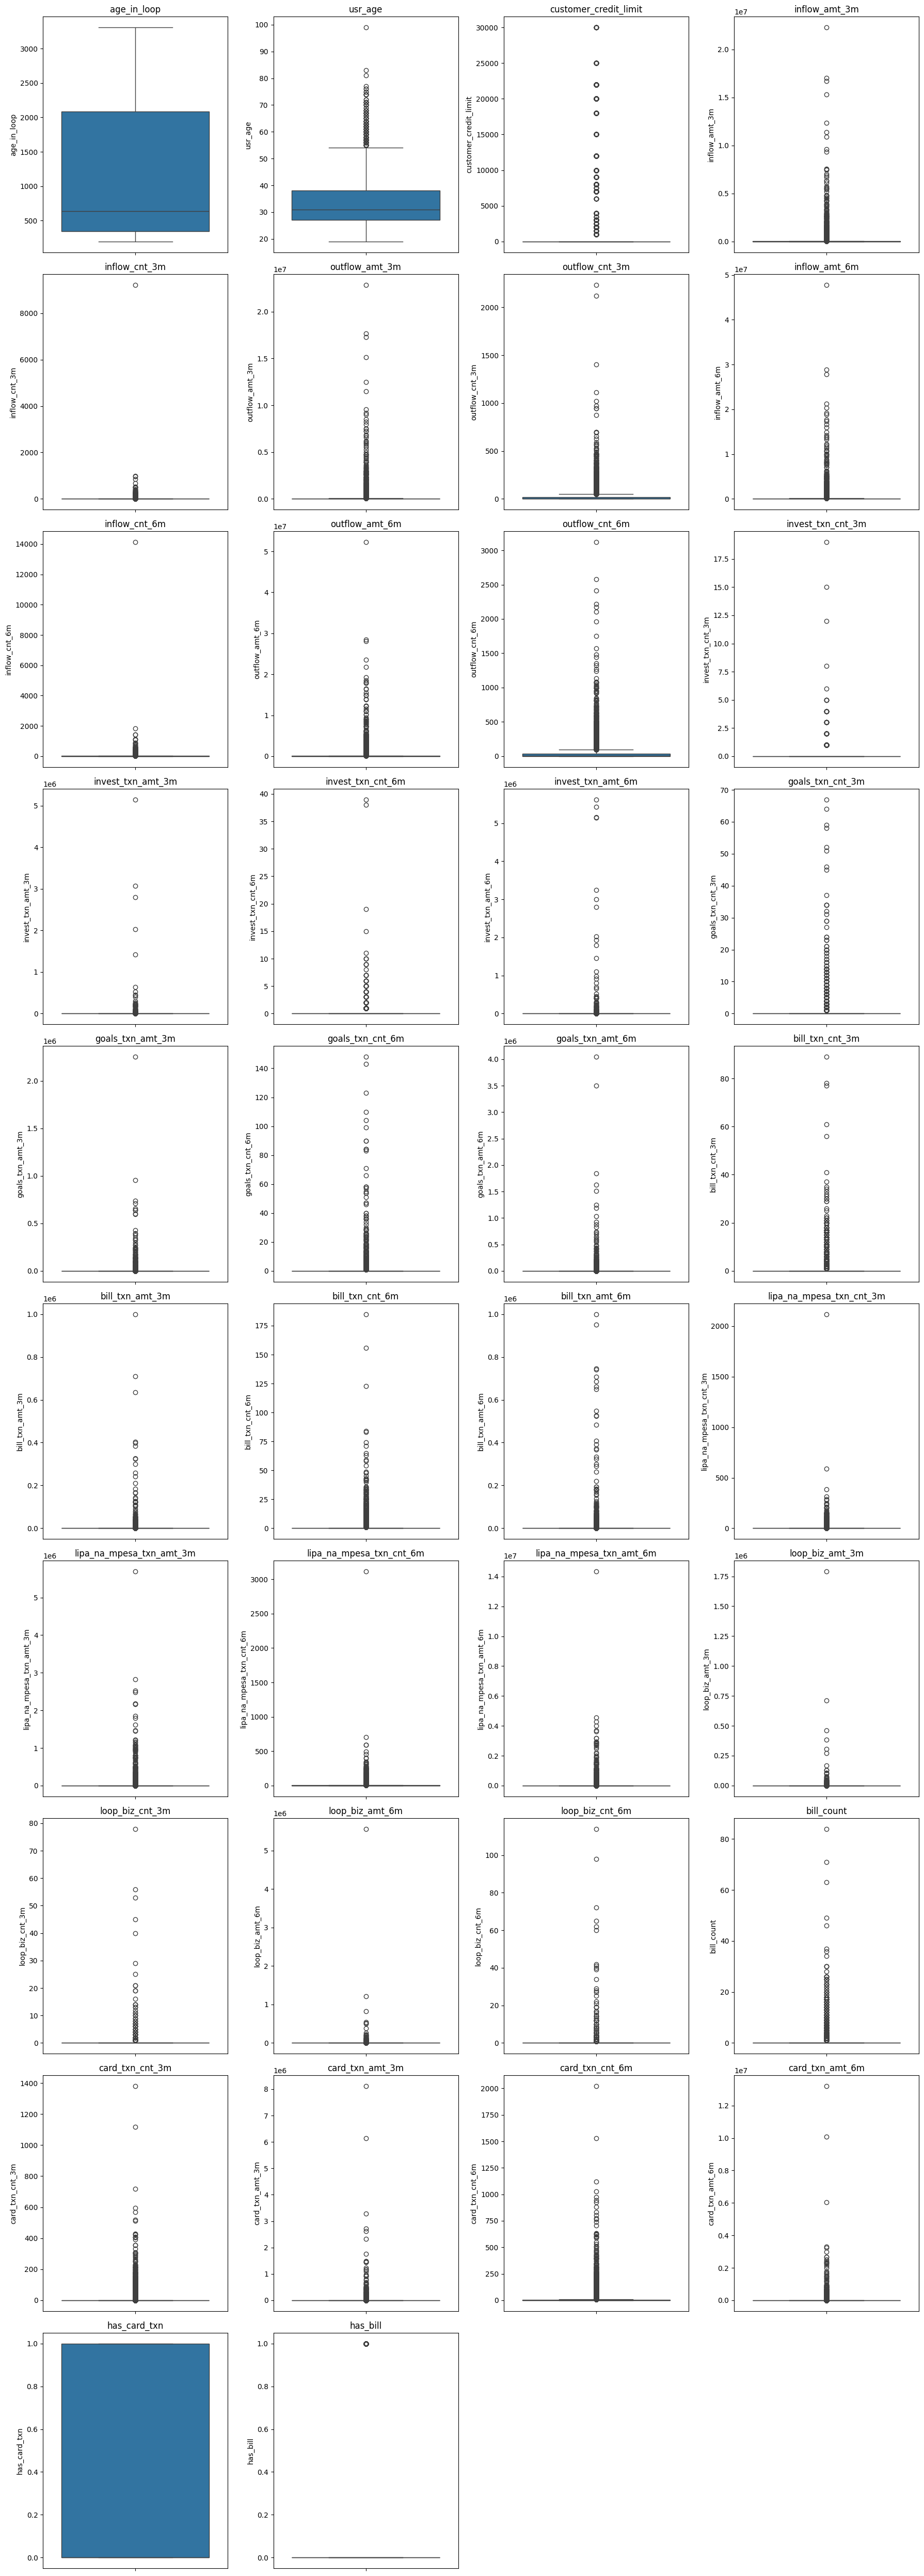

In [351]:
num_cols = df2.select_dtypes(include=[np.number]).columns
num_cols = [col for col in num_cols if col != 'customer_number']
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df2[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### **Apply Log Transformation**

**This handles Skeewness and stabilize variance**

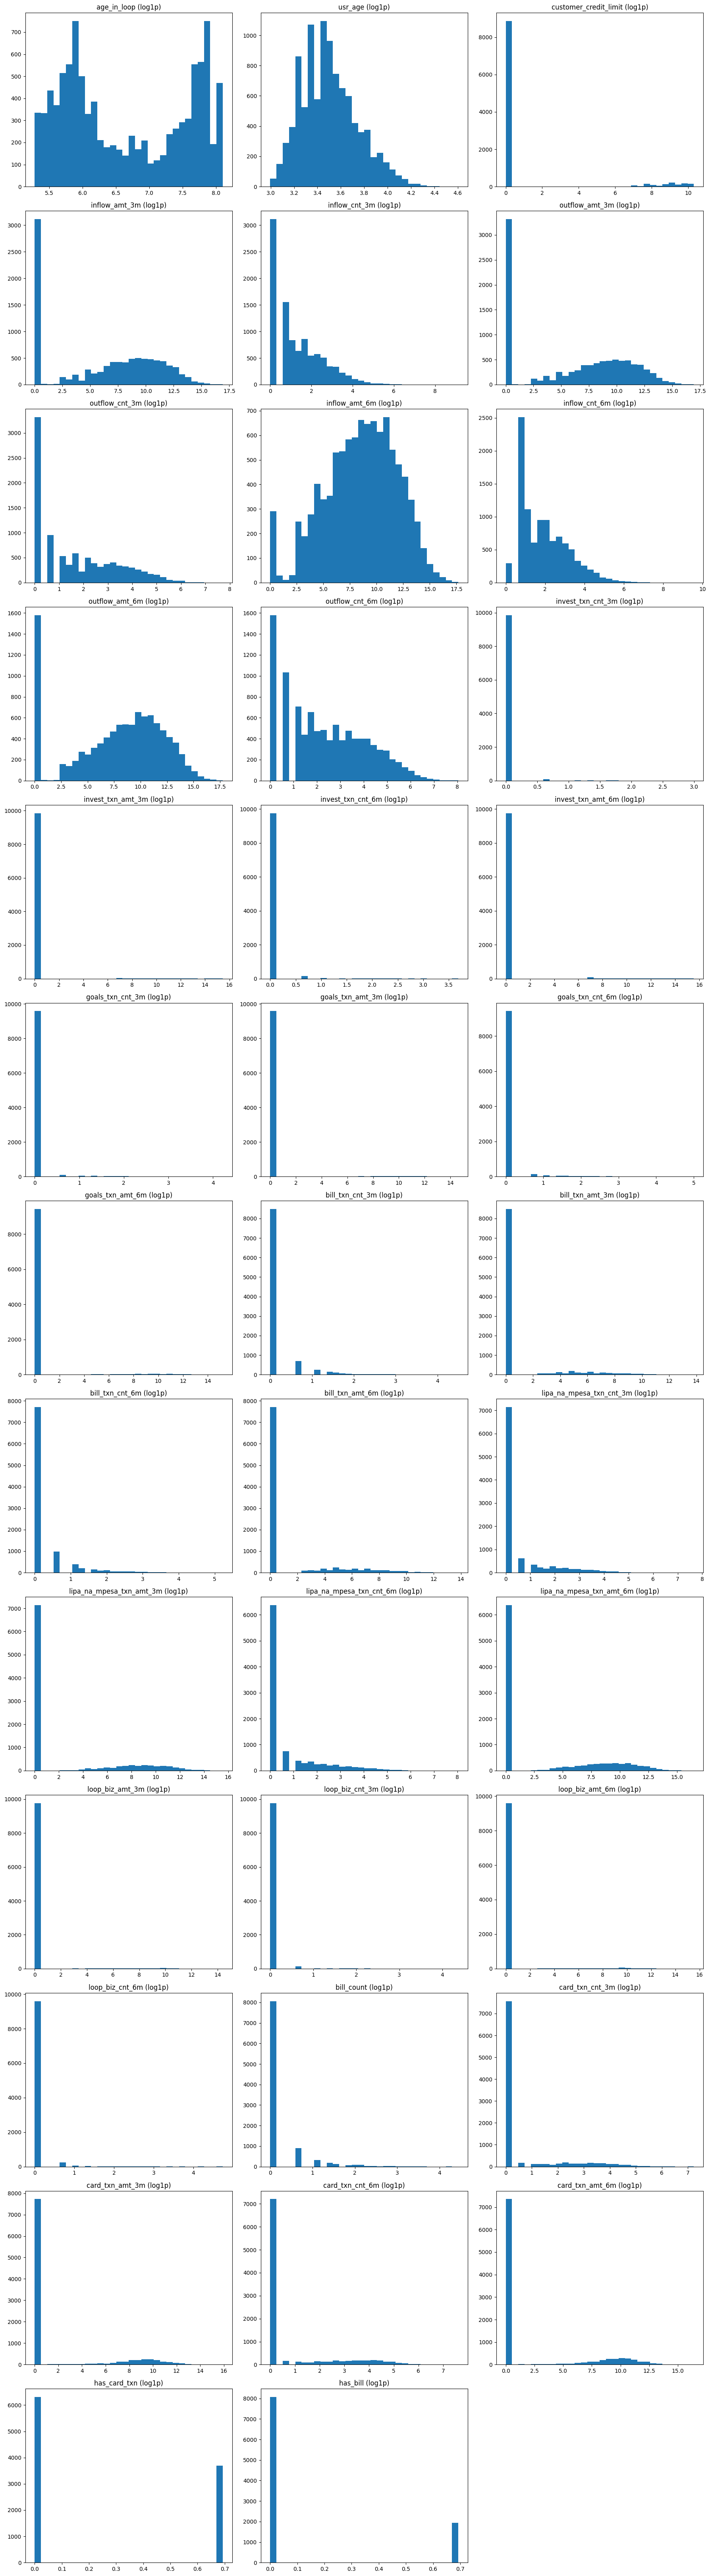

In [352]:
df_log = df2.copy()

num_cols = df_log.select_dtypes(include=[np.number]).columns.tolist()
if 'customer_number' in num_cols:
    num_cols.remove('customer_number')

exclude_cols = ['has_virtual_card']  # add more if needed
log_cols = [col for col in num_cols if col not in exclude_cols]

for col in log_cols:
    df_log[col] = np.log1p(df_log[col])

n_cols = 3
n_rows = int(np.ceil(len(log_cols) / n_cols))

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(log_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_log[col], bins=30)
    plt.title(f"{col} (log1p)")

plt.tight_layout()
plt.show()



#### Boxplots (After Log transformation)

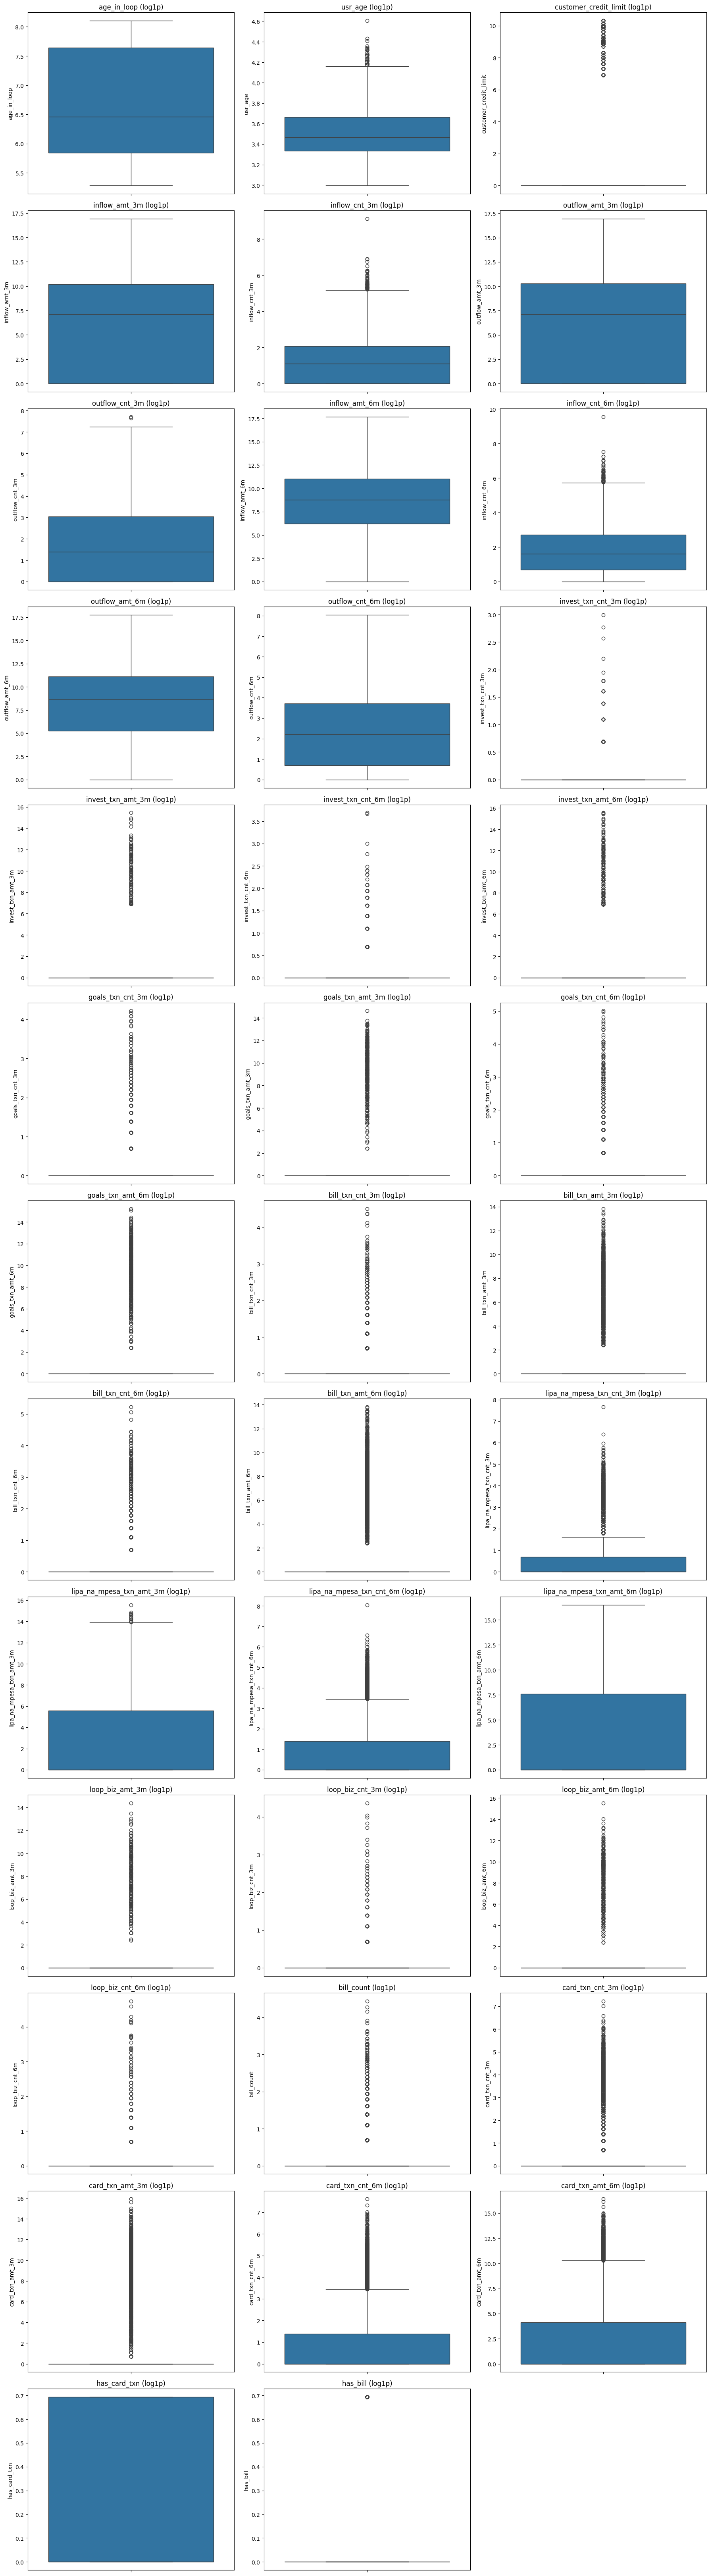

In [353]:

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(log_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_log[col])
    plt.title(f"{col} (log1p)")

plt.tight_layout()
plt.show()

#### **Now apply IQR to detect outliers per feature**

In [354]:
df = df_log.copy()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'customer_number' in num_cols:
    num_cols.remove('customer_number')

iqr_results = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    iqr_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers.shape[0],
        "Outlier_Percent": round((outliers.shape[0] / df.shape[0]) * 100, 2)
    })

iqr_table = pd.DataFrame(iqr_results)

iqr_table = iqr_table.sort_values(by="Outlier_Percent", ascending=False)

iqr_table

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
32,card_txn_cnt_3m,0.000000,0.000000,0.000000,0.000000,0.000000,2432,24.32
21,bill_txn_cnt_6m,0.000000,0.000000,0.000000,0.000000,0.000000,2293,22.93
22,bill_txn_amt_6m,0.000000,0.000000,0.000000,0.000000,0.000000,2293,22.93
33,card_txn_amt_3m,0.000000,0.000000,0.000000,0.000000,0.000000,2277,22.77
37,has_bill,0.000000,0.000000,0.000000,0.000000,0.000000,1936,19.36
31,bill_count,0.000000,0.000000,0.000000,0.000000,0.000000,1936,19.36
20,bill_txn_amt_3m,0.000000,0.000000,0.000000,0.000000,0.000000,1517,15.17
19,bill_txn_cnt_3m,0.000000,0.000000,0.000000,0.000000,0.000000,1517,15.17
23,lipa_na_mpesa_txn_cnt_3m,0.000000,0.693147,0.693147,-1.039721,1.732868,1505,15.05
34,card_txn_cnt_6m,0.000000,1.386294,1.386294,-2.079442,3.465736,1288,12.88


#### **Explanation**
* The IQR results show that most of the transactional and product usage features are highly zero-inflated, meaning the majority of customers do not use services like cards, bills, investments, or loop business products, while a smaller group exhibits active usage, these appear as “outliers” under the IQR rule but are actually meaningful behavioral segments rather than true anomalies. This makes the dataset strongly suitable for customer segmentation because the variation is driven by engagement levels rather than noise; therefore, these features should be retained and interpreted as activity indicators (often better represented using binary usage flags), while continuous financial variables like inflow and outflow amounts provide the stable structure for clustering.


#### **Feature Engineering**

##### **Create New Features to enrich our dataset**

In [355]:
# CORE FLOW FEATURES

df['net_flow_3m'] = df['inflow_amt_3m'] - df['outflow_amt_3m']
df['net_flow_6m'] = df['inflow_amt_6m'] - df['outflow_amt_6m']
df['flow_consistency'] = df['net_flow_3m'] / (df['net_flow_6m'] + 1)

#  RATIOS & ACTIVITY

df['inflow_outflow_ratio_3m'] = df['inflow_amt_3m'] / (df['outflow_amt_3m'] + 1)
df['txn_activity_3m'] = df['inflow_cnt_3m'] + df['outflow_cnt_3m']
df['avg_txn_value_3m'] = df['inflow_amt_3m'] / (df['inflow_cnt_3m'] + 1)
df['spend_per_txn_3m'] = df['outflow_amt_3m'] / (df['outflow_cnt_3m'] + 1)


# GROWTH / TREND

df['inflow_growth'] = (df['inflow_amt_3m'] - df['inflow_amt_6m']/2) / (df['inflow_amt_6m']/2 + 1)
df['outflow_growth'] = (df['outflow_amt_3m'] - df['outflow_amt_6m']/2) / (df['outflow_amt_6m']/2 + 1)

df['txn_freq_change'] = (
    (df['inflow_cnt_3m'] + df['outflow_cnt_3m']) -
    (df['inflow_cnt_6m'] + df['outflow_cnt_6m'])/2
)

# CHANNEL USAGE

df['lipa_ratio_3m'] = df['lipa_na_mpesa_txn_amt_3m'] / (df['outflow_amt_3m'] + 1)
df['card_usage_ratio'] = df['card_txn_amt_3m'] / (df['outflow_amt_3m'] + 1)
df['biz_ratio_3m'] = df['loop_biz_amt_3m'] / (df['inflow_amt_3m'] + 1)


# ENGAGEMENT

df['product_engagement'] = (
    df['invest_txn_cnt_3m'] +
    df['goals_txn_cnt_3m'] +
    df['bill_txn_cnt_3m'] +
    df['lipa_na_mpesa_txn_cnt_3m']
)

df['investment_ratio'] = df['invest_txn_amt_3m'] / (df['inflow_amt_3m'] + 1)
df['goals_ratio'] = df['goals_txn_amt_3m'] / (df['inflow_amt_3m'] + 1)


# CREDIT BEHAVIOR

df['credit_utilization'] = df['outflow_amt_3m'] / (df['customer_credit_limit'] + 1)
df['high_spender_flag'] = (df['credit_utilization'] > 0.8).astype(int)

# INTENSITY SCORE
df['customer_intensity'] = (
    df['txn_activity_3m'] +
    df['product_engagement'] +
    df['lipa_na_mpesa_txn_cnt_3m']
)

#  BEHAVIORAL FLAGS

df['income_dependency'] = df['inflow_amt_3m'] / (df['inflow_amt_6m'] + 1)
df['is_low_activity'] = (df['txn_activity_3m'] < 5).astype(int)
df['is_power_user'] = (df['txn_activity_3m'] > df['txn_activity_3m'].quantile(0.9)).astype(int)


# ADDITIONAL ADVANCED FEATURES

df['flow_volatility'] = (df['inflow_amt_3m'] - df['outflow_amt_3m']).abs() / (df['inflow_amt_6m'] + df['outflow_amt_6m'] + 1)

df['service_diversity'] = (
    (df['invest_txn_cnt_3m'] > 0).astype(int) +
    (df['goals_txn_cnt_3m'] > 0).astype(int) +
    (df['bill_txn_cnt_3m'] > 0).astype(int) +
    (df['lipa_na_mpesa_txn_cnt_3m'] > 0).astype(int) +
    (df['card_txn_cnt_3m'] > 0).astype(int)
)

df['digital_maturity'] = (
    df['card_txn_cnt_3m'] +
    df['lipa_na_mpesa_txn_cnt_3m'] +
    df['loop_biz_cnt_3m']
)

df['saving_behavior'] = df['inflow_amt_3m'] / (df['outflow_amt_3m'] + df['inflow_amt_3m'] + 1)
df['spending_pressure'] = df['outflow_amt_3m'] / (df['inflow_amt_3m'] + 1)

df['activity_per_tenure'] = df['txn_activity_3m'] / (df['age_in_loop'] + 1)

df['high_value_customer'] = (
    (df['inflow_amt_3m'] > df['inflow_amt_3m'].quantile(0.9)) &
    (df['outflow_amt_3m'] > df['outflow_amt_3m'].quantile(0.9))
).astype(int)


#### **Explanation**
* These engineered features convert raw transactional and product usage data into compact behavioral signals that capture customer cash flow dynamics, spending and saving patterns, digital channel preference, engagement intensity, and credit utilization behavior. This allows clustering models to segment customers based on meaningful financial behavior and usage profiles.

#### **Drop Original Redundant Features**

In [356]:
drop_cols = [
    'inflow_amt_3m', 'outflow_amt_3m',
    'inflow_amt_6m', 'outflow_amt_6m',
    'inflow_cnt_3m', 'outflow_cnt_3m',
    'inflow_cnt_6m', 'outflow_cnt_6m',
    'invest_txn_cnt_3m', 'invest_txn_amt_3m',
    'invest_txn_cnt_6m', 'invest_txn_amt_6m',
    'goals_txn_cnt_3m', 'goals_txn_amt_3m',
    'goals_txn_cnt_6m', 'goals_txn_amt_6m',
    'bill_txn_cnt_3m', 'bill_txn_amt_3m',
    'bill_txn_cnt_6m', 'bill_txn_amt_6m',
    'lipa_na_mpesa_txn_cnt_3m', 'lipa_na_mpesa_txn_amt_3m',
    'lipa_na_mpesa_txn_cnt_6m', 'lipa_na_mpesa_txn_amt_6m',
    'loop_biz_amt_3m', 'loop_biz_cnt_3m',
    'loop_biz_amt_6m', 'loop_biz_cnt_6m',
    'card_txn_cnt_3m', 'card_txn_amt_3m',
    'card_txn_cnt_6m', 'card_txn_amt_6m',
    'customer_credit_limit'
]

df = df.drop(columns=drop_cols, errors='ignore')



#### **Drop Original Redundant Features**

* After feature engineering, the original transactional and product-level variables were dropped to eliminate redundancy and prevent duplication of information in the dataset. This was necessary because most raw features were already transformed into higher-level behavioral indicators such as net flow, transaction intensity, engagement scores, and usage ratios.

* Retaining both raw and engineered features would introduce multicollinearity, inflate dimensionality, and potentially bias distance-based clustering algorithms like KMeans. By removing the original features, the dataset becomes more compact, computationally efficient, and better structured for unsupervised learning. This ensures that clustering is driven purely by meaningful behavioral representations rather than repetitive raw signals.

In [357]:
df.columns

Index(['customer_number', 'age_in_loop', 'usr_age', 'bill_count',
       'has_virtual_card', 'has_card_txn', 'has_bill', 'net_flow_3m',
       'net_flow_6m', 'flow_consistency', 'inflow_outflow_ratio_3m',
       'txn_activity_3m', 'avg_txn_value_3m', 'spend_per_txn_3m',
       'inflow_growth', 'outflow_growth', 'txn_freq_change', 'lipa_ratio_3m',
       'card_usage_ratio', 'biz_ratio_3m', 'product_engagement',
       'investment_ratio', 'goals_ratio', 'credit_utilization',
       'high_spender_flag', 'customer_intensity', 'income_dependency',
       'is_low_activity', 'is_power_user', 'flow_volatility',
       'service_diversity', 'digital_maturity', 'saving_behavior',
       'spending_pressure', 'activity_per_tenure', 'high_value_customer'],
      dtype='object')

#### **Save for Deployment Phase**

In [358]:
df_model = df.copy()

customer_ids = df['customer_number']
df_model = df.drop(columns=['customer_number'])

#### **Apply encoding to categorical features**

In [359]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df_model.select_dtypes(include=['object']).columns

le = LabelEncoder()

for col in cat_cols:
    df_model[col] = df_model[col].astype(str)  # ensure consistency
    df_model[col] = le.fit_transform(df_model[col])

#### **Explanation**

* Label encoding was applied to convert categorical variables into a numerical format suitable for machine learning algorithms. Since most clustering and scaling techniques require numeric inputs, categorical features such as binary indicators (e.g., Yes/No variables) were transformed into integer representations.

* Each unique category within a feature was assigned a distinct numeric value, ensuring that the information contained in the categorical variable was preserved in a machine-readable form. This step enabled the inclusion of categorical behavioral signals in the modeling pipeline without introducing missing values or requiring manual feature exclusion. It also ensured compatibility with downstream processes such as scaling, PCA, and clustering.

#### **Correlation Prunning**

In [360]:
corr_matrix = df_model.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

df_model = df_model.drop(columns=to_drop)

print("Dropped due to correlation:", to_drop)
print("Remaining features:", df_model.shape)

Dropped due to correlation: ['txn_freq_change', 'customer_intensity', 'income_dependency', 'saving_behavior', 'activity_per_tenure']
Remaining features: (10000, 30)


#### **Correlation Pruning (> 0.90)**

* Correlation pruning is a feature selection technique used to remove highly correlated variables from the dataset before model training. In this project, a threshold of **0.90** was applied, meaning that any pair of features with a correlation coefficient greater than 0.90 was considered highly redundant.

* Highly correlated features carry nearly identical information, which can introduce multicollinearity, inflate model complexity, and bias distance-based algorithms such as KMeans. By removing one feature from each highly correlated pair, the dataset is simplified while preserving the most informative signals. This improves computational efficiency, enhances model stability, and ensures that clustering is driven by distinct behavioral patterns rather than duplicated information.


#### Scale the Dataset

In [361]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

#### **Select the Best Cluster Number**

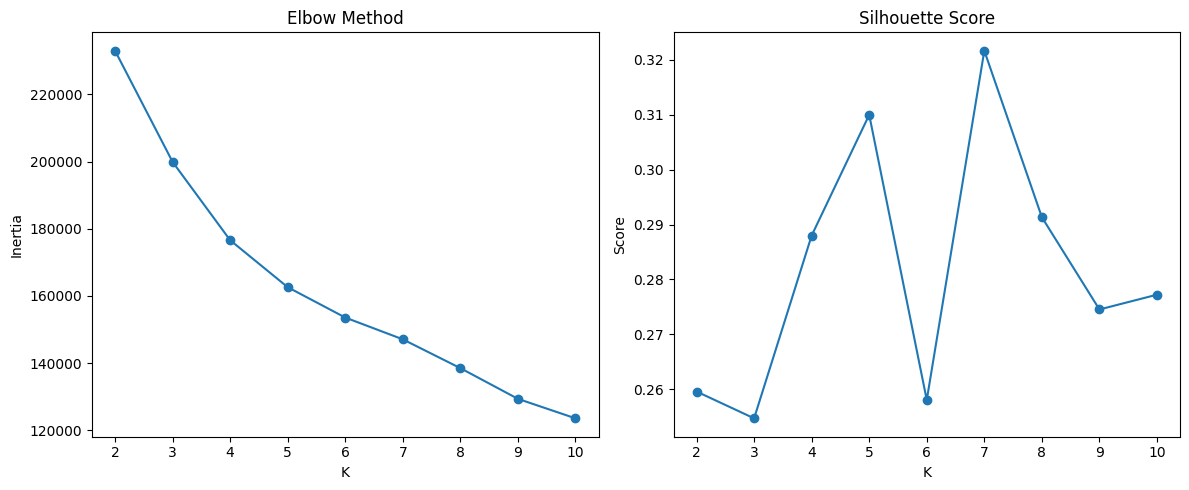

In [362]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

# Plot Silhouette 
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

#### **Observation**

* The optimal number of clusters (K) for the KMeans algorithm was determined to be **3**, based on evaluation using the Silhouette Score. The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters, effectively capturing both cohesion (how close points are within a cluster) and separation (how distinct clusters are from each other).

* A K value of 3 produced the highest and most stable Silhouette Score among the tested range, indicating that the dataset naturally forms three well-separated customer segments. This suggests that increasing or decreasing the number of clusters would either merge distinct behavioral groups or introduce unnecessary fragmentation, reducing interpretability and model performance. Therefore, K = 3 was selected as the most suitable configuration for meaningful and business-aligned customer segmentation.

#### **Apply PCA but careful to avoid Information loss**

In [363]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("Reduced PCA components:", X_pca.shape[1])

Original features: 30
Reduced PCA components: 18


#### **Explained Variance from the PCA**

In [364]:
print("Explained variance ratio sum:", np.sum(pca.explained_variance_ratio_))

Explained variance ratio sum: 0.9575138738317686


##### **Explanation**
* The explained variance ratio sum of **0.9575** indicates that the PCA transformation retains approximately **95.75% of the total information (variance)** from the original feature set. This means the dimensionality reduction process has successfully compressed the data while preserving nearly all the underlying structure and patterns, ensuring minimal information loss. As a result, the transformed dataset remains highly representative of the original behavioral signals, making it well-suited for clustering while improving efficiency, reducing noise, and mitigating redundancy among correlated features.


#### **Apply K-Means for clustering**

In [365]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

#### **Apply DBSCAN**

In [366]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_pca)

#### **Plot their clusters**

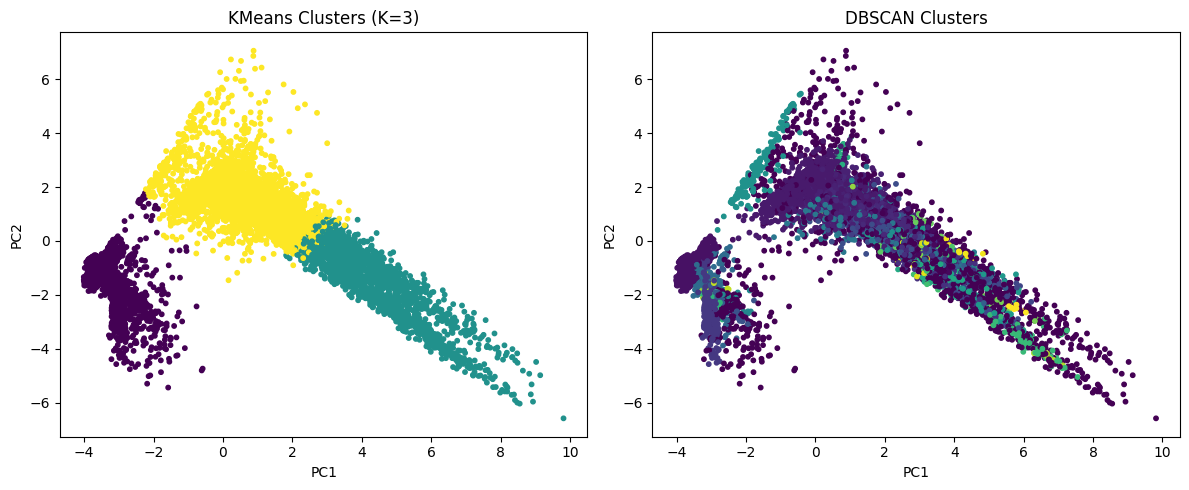

In [367]:
pca_2d = PCA(n_components=2)
X_vis = pca_2d.fit_transform(X_scaled)

# KMeans plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_vis[:,0], X_vis[:,1], c=kmeans_labels, cmap='viridis', s=10)
plt.title("KMeans Clusters (K=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# DBSCAN plot

plt.subplot(1,2,2)
plt.scatter(X_vis[:,0], X_vis[:,1], c=dbscan_labels, cmap='viridis', s=10)
plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

#### **Comparison to show the best Clustering Model**

In [368]:
print("KMeans cluster sizes:")
print(np.unique(kmeans_labels, return_counts=True))

print("\nDBSCAN cluster sizes (-1 = noise):")
print(np.unique(dbscan_labels, return_counts=True))

KMeans cluster sizes:
(array([0, 1, 2], dtype=int32), array([3355, 1971, 4674]))

DBSCAN cluster sizes (-1 = noise):
(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42]), array([1851,  330, 2141, 1778,  830,  403,  165,  460,  132,   53,  236,
         25,   57,   44,   17,  282,   71,  212,   43,  101,   40,   43,
        195,   73,   29,   33,   38,   35,   24,   75,   23,   15,   12,
         12,   15,   15,   15,   14,   11,   12,   11,   11,    8,   10]))


#### **Explanation**
* The KMeans results show a clear and stable segmentation of customers into three distinct groups, with the largest cluster (4,674 users) representing the core customer base with standard or low-to-moderate engagement, a second cluster (3,355 users) representing moderately active users with higher transactional and multi-channel usage, and a smaller cluster (1,971 users) representing high-intensity or specialized users with stronger financial activity and engagement patterns. In contrast, DBSCAN produced many small clusters alongside a large noise group, indicating that while there are fine-grained behavioral variations in the data, the structure is too continuous and high-dimensional for density-based clustering to form stable, business-meaningful segments. Overall, this confirms that KMeans with three clusters provides the most interpretable and practical segmentation for business use.


#### **Attach Clusters back to the Dataset**

In [369]:
df_profile = df.copy()
df_profile['cluster'] = kmeans_labels

#### **Cluster Summary**

In [370]:
cluster_summary = df_profile.groupby('cluster').mean(numeric_only=True).T
cluster_summary

cluster,0,1,2
age_in_loop,6.527703,7.132781,6.551070
usr_age,3.508410,3.528132,3.495440
bill_count,0.066727,0.752995,0.139862
has_card_txn,0.113837,0.497265,0.256853
has_bill,0.044832,0.374883,0.096839
net_flow_3m,0.953819,-0.078812,-0.521263
net_flow_6m,2.438068,-0.067322,-0.144875
flow_consistency,-0.042737,0.452100,-0.223025
inflow_outflow_ratio_3m,0.969931,0.914275,0.805361
txn_activity_3m,0.167600,7.140516,3.334560


#### **Cluster Size Business importance**

In [371]:
df_profile['cluster'].value_counts().sort_index()

cluster
0    3355
1    1971
2    4674
Name: count, dtype: int64

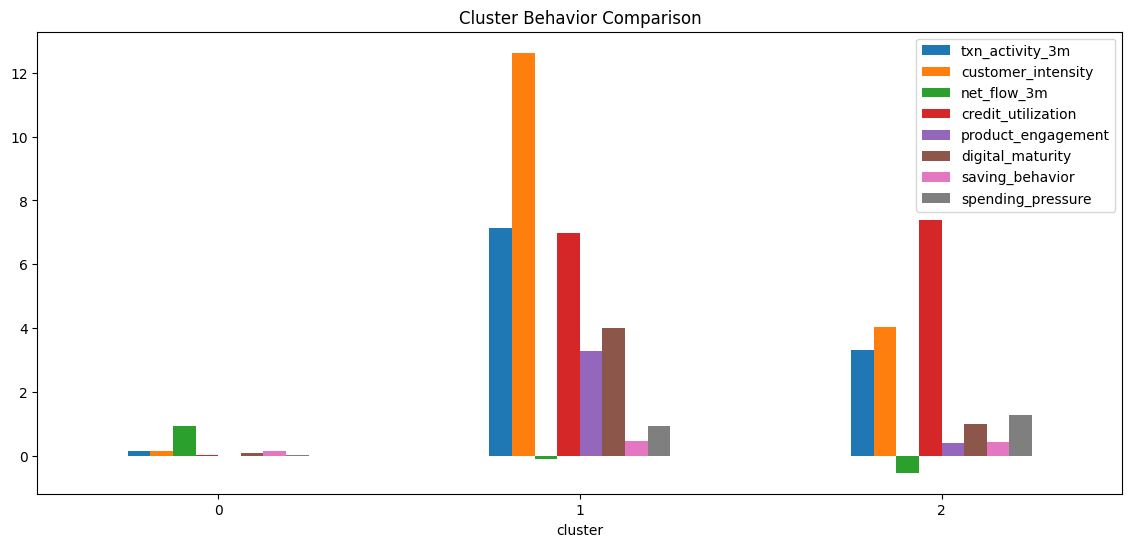

In [372]:
key_cols = [
    'txn_activity_3m',
    'customer_intensity',
    'net_flow_3m',
    'credit_utilization',
    'product_engagement',
    'digital_maturity',
    'saving_behavior',
    'spending_pressure'
]

cluster_means = df_profile.groupby('cluster')[key_cols].mean()

cluster_means.plot(kind='bar', figsize=(14,6))
plt.title("Cluster Behavior Comparison")
plt.xticks(rotation=0)
plt.show()

#### **Business Impact Summary**

####  **Explanations**
#####  **Cluster 0 — Dormant / Low-Engagement Users**

* This segment consists of customers with consistently low transactional activity and minimal engagement with financial products. They show very low product usage across investments, goals, bills, and card services, alongside extremely low digital maturity and service diversity. Their behavior suggests they primarily use accounts in a passive way, likely for basic inflows or occasional transactions, rather than active financial management. The high “low activity” indicator further confirms that this group has limited interaction with the platform’s ecosystem.

* From a business perspective, this is a **reactivation and onboarding opportunity segment**. These customers contribute little immediate value but represent significant future potential if successfully engaged. Targeted strategies such as digital education, simplified product onboarding, and awareness campaigns could help convert them into active users. Reducing dormancy in this group directly improves overall customer base efficiency and long-term retention.


##### **Cluster 1 — High-Value Digital Power Users**

* This cluster represents the most active and valuable customers in the dataset. They exhibit extremely high transaction activity, strong product engagement, high service diversity, and advanced digital maturity. They actively use multiple financial channels such as cards, bill payments, and mobile money services, and demonstrate strong inflow and outflow growth patterns. Their high credit utilization and intensity scores indicate deep financial involvement and consistent platform reliance.

* From a business standpoint, this is the **core revenue-driving segment**. These customers should be prioritized for retention, loyalty programs, premium financial products, and cross-selling opportunities such as investments and credit enhancements. Maintaining satisfaction and deepening their engagement is critical, as they contribute disproportionately to revenue and overall platform activity.



##### **Cluster 2 — Active Mass Market / Basic Users**

* This segment represents the largest group of customers who are moderately active but relatively unsophisticated in their financial behavior. They show moderate transaction activity but low product engagement and limited service diversification. While they participate in basic financial flows, they rarely adopt advanced services such as investments, goals, or business-related products. Their digital maturity is average, indicating partial adoption of digital financial tools.

* From a business perspective, this is a **growth and upselling segment**. These customers already generate consistent transaction volume but have not fully adopted the broader product ecosystem. They present strong potential for expansion through targeted cross-selling, digital adoption campaigns, and financial literacy initiatives. Improving their engagement depth can significantly increase lifetime value at scale due to their large population size.


#### **Save now For Deployment**

In [373]:
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca_model.pkl")
joblib.dump(df_model, "training_data.pkl")
joblib.dump(customer_ids, "customer_ids.pkl")

joblib.dump(df_model.drop(columns=['cluster'], errors='ignore').columns.tolist(), "features.pkl")

['features.pkl']

### **Final Summary Documentation**

### CUSTOMER SEGMENTATION USING MACHINE LEARNING

#### End-to-End Technical Documentation


#### 1. PROJECT OVERVIEW

This project focuses on developing a customer segmentation system using machine learning to group customers based on behavioral, transactional, and financial patterns. The objective is to transform raw banking data into actionable customer segments that support decision-making in marketing, risk management, and product personalization.

The solution follows a complete machine learning lifecycle including data validation, preprocessing, feature engineering, dimensionality reduction, clustering, and deployment.

#### 2. DATA VALIDATION

###### 2.1 Schema and Structure Validation

The dataset was validated to ensure:

* Correct feature data types (numeric vs categorical)
* Proper identification of key fields such as customer identifiers
* Consistency between 3-month and 6-month transactional features

##### 2.2 Missing Data Analysis

A significant number of features exhibited missing values, especially transactional and product usage variables. These were analyzed based on business meaning:

* Features representing inactivity were treated as valid zeros
* Highly sparse variables were evaluated for relevance or exclusion
* Credit and engagement variables were carefully assessed to preserve behavioral signals

##### 2.3 Data Quality Issues

The dataset contained:

* Mixed categorical and numerical encodings (e.g., Yes/No values)
* Highly skewed distributions typical of financial transactions
* Redundant features across multiple time windows
* Zero-inflated behavioral variables indicating inactive usage patterns

#### 3. DATA PREPARATION

##### 3.1 Categorical Encoding

Binary categorical variables were converted into numeric format using label encoding to ensure compatibility with machine learning models.

###### 3.2 Missing Value Strategy

Two main strategies were applied:

* Zero imputation for transactional inactivity features
* Selective retention or exclusion based on business relevance

##### 3.3 Outlier Analysis

Outliers were identified using the Interquartile Range (IQR) method. Many financial features showed zero-inflated distributions, and therefore outlier removal was not applied aggressively to avoid loss of meaningful behavioral extremes.

##### 3.4 Feature Scaling

StandardScaler was applied to normalize feature distributions before clustering to ensure equal contribution of all variables.


#### 4. FEATURE ENGINEERING

Feature engineering was a critical step in transforming raw transactional data into meaningful behavioral indicators.

###### 4.1 Financial Flow Features

* Net inflow and outflow for 3-month and 6-month periods
* Flow consistency ratios
* Inflow-to-outflow ratios

These features capture customer financial stability and liquidity behavior.

##### 4.2 Activity-Based Features

* Total transaction activity
* Average transaction value
* Spending per transaction

These measure customer engagement intensity.

##### 4.3 Behavioral Trend Features

* Growth in inflows and outflows
* Transaction frequency changes

These capture changes in financial behavior over time.

##### 4.4 Channel Usage Features

* Card usage ratios
* Mobile money (Lipa na M-Pesa) usage
* Business transaction usage

These identify preferred financial channels.

##### 4.5 Engagement Features

* Product engagement score across investments, goals, bills, and payments
* Investment and savings ratios

These measure financial product adoption depth.

##### 4.6 Credit Behavior Features

* Credit utilization ratio
* High spender indicator

These capture credit dependency and risk behavior.

##### 4.7 Composite Behavioral Indicators

* Customer intensity score
* Digital maturity index
* Service diversity index

These summarize overall financial sophistication.

##### 4.8 Behavioral Flags

* Low activity indicator
* Power user indicator
* High value customer indicator


#### 5. DIMENSIONALITY REDUCTION (PCA)

Principal Component Analysis (PCA) was applied to reduce multicollinearity and compress the feature space.

* Retained variance: 95.75%
* Result: Significant dimensionality reduction with minimal information loss

This ensured that clustering was performed on a stable and noise-reduced representation of the data.


#### 6. MODEL DEVELOPMENT (CLUSTERING)

##### 6.1 Algorithm Selection

Multiple clustering algorithms were evaluated:

* KMeans: Selected for interpretability and stability
* DBSCAN: Used for exploratory analysis but produced overly fragmented clusters

##### 6.2 Optimal Cluster Selection

The optimal number of clusters was determined using:

* Elbow Method (inertia analysis)
* Silhouette Score evaluation

The optimal value was determined as:

* K = 3

###### 6.3 Final Model

A KMeans model with three clusters was trained on PCA-transformed features.

#### 7. CUSTOMER SEGMENTATION RESULTS

##### Cluster 0 — Dormant / Low Engagement Users

This segment consists of customers with very low transactional activity and minimal engagement with financial products. They exhibit low digital maturity, limited product adoption, and minimal interaction with the financial ecosystem.

From a business perspective, this segment represents a reactivation opportunity group. Targeted strategies such as onboarding campaigns, digital education, and awareness initiatives can help increase engagement and retention.


##### Cluster 1 — High-Value Digital Power Users

This segment represents highly active and digitally mature customers with strong engagement across multiple financial products. They exhibit high transaction intensity, diversified service usage, and strong credit utilization patterns.

This group represents the primary revenue-driving segment and should be prioritized for premium offerings, loyalty programs, credit products, and cross-selling opportunities.


##### Cluster 2 — Active Mass Market Users

This is the largest segment, consisting of moderately active customers with basic financial engagement. While they participate in transactions regularly, their product adoption and digital sophistication remain low.

This segment presents strong opportunities for cross-selling, digital adoption strategies, and product penetration initiatives to increase lifetime value.



#### 8. MODEL DEPLOYMENT

The final clustering model was deployed using **FastAPI**, enabling real-time customer segmentation through API-based inference. The system allows customer-level queries using a unique customer identifier, returning the predicted segment along with its business interpretation.

This design ensures:

* Fast and scalable inference
* Integration with external systems (CRM, banking platforms)
* Structured API-based access for production environments



#### 9. SCALABILITY AND PRODUCTION READINESS

The system was designed with scalability in mind using modern MLOps principles:

##### 9.1 Containerization (Docker)

The application can be containerized using Docker to ensure:

* Environment consistency across development and production
* Easy deployment across multiple infrastructures
* Dependency isolation and version control

##### 9.2 Orchestration

The system is suitable for orchestration using tools such as Kubernetes, enabling:

* Horizontal scaling of API services
* Load balancing across multiple containers
* Fault tolerance and high availability
* Automated deployment and updates

This ensures the solution can operate efficiently in enterprise-scale environments with high traffic and real-time prediction requirements.


#### 10. CONCLUSION

This project demonstrates a complete end-to-end machine learning pipeline for customer segmentation, transforming raw financial transaction data into actionable business intelligence. Through careful data validation, feature engineering, dimensionality reduction, and clustering, the system successfully identifies meaningful customer groups.

The deployment using FastAPI, combined with Dockerization and orchestration readiness, ensures that the solution is production-grade, scalable, and suitable for real-world financial environments.
